Que tal praticar?
Este é o projeto que fecha sua jornada no curso e simula o dia a dia real de um Cientista de Dados: você vai receber três bases de dados diferentes, cada uma escondendo uma oportunidade de projeto, e será sua responsabilidade identificar o problema, definir a abordagem e construir a solução do zero — exatamente como acontece quando um time de dados recebe uma base "crua" de um cliente ou de outra área da empresa. Aqui entram todas as competências desenvolvidas ao longo do curso: da preparação e exploração dos dados até a escolha, treinamento e avaliação criteriosa do modelo. Mais do que rodar um algoritmo, o objetivo é demonstrar que você consegue conduzir um projeto de dados completo, com julgamento técnico e comunicação clara dos resultados.

O que você vai desenvolver com esse exercício
Capacidade de identificar e definir um problema de negócio a partir de uma base de dados bruta
Condução completa de uma Análise Exploratória de Dados (EDA), com múltiplas técnicas
Preparação de dados para modelagem, sem vazamento de dados (data leakage)
Treinamento e avaliação criteriosa de um modelo de classificação binária
Interpretação de resultados conectada ao problema de negócio, não apenas à métrica
O contexto do desafio
Serão disponibilizadas três bases de dados diferentes, cada uma contendo uma oportunidade de projeto que você mesmo deve identificar. Você escolherá uma dessas bases para trabalhar e aplicará todos os conceitos vistos ao longo do curso — desde a preparação do dado e o desenvolvimento do problema a ser solucionado, até a escolha do modelo e sua avaliação final.

O que deve ser entregue
Definição explícita do problema de negócio, do tipo de tarefa de Machine Learning e da variável-alvo escolhida
Análise Exploratória de Dados completa, com seção textual consolidando os principais insights
Base de dados higienizada e preparada para modelagem (tratamento de ausentes, tipagem, encoding)
Separação treino/teste feita antes das transformações sensíveis, sem vazamento de dados
Modelo de classificação binária treinado e avaliado com métricas apropriadas, com interpretação do resultado

Passo a passo
Escolha uma das três bases de dados disponibilizadas e identifique a oportunidade de projeto nela contida.
Defina explicitamente o problema de negócio, o tipo de tarefa de Machine Learning (classificação binária) e a variável-alvo.
Aplique pelo menos 5 técnicas distintas de Análise Exploratória de Dados sobre os dados reais da base escolhida.
Escreva uma seção textual consolidando os principais insights obtidos na fase exploratória.
Higienize e prepare os dados para a modelagem: trate valores ausentes, ajuste a tipagem e codifique as variáveis categóricas (encoding).
Separe os dados em treino e teste antes de aplicar qualquer transformação sensível, evitando vazamento de dados (data leakage).
Treine pelo menos um modelo apropriado para a tarefa de classificação binária definida.
Avalie o modelo com as métricas corretas para o problema e interprete o resultado — não basta apenas imprimir os números, é preciso explicar o que eles significam para o negócio.

Requisitos obrigatórios
A avaliação confere se o problema de negócio e a variável-alvo foram claramente definidos, se a EDA foi conduzida com profundidade (mínimo de 5 técnicas e insights consolidados), se os dados foram preparados sem vazamento de dados e se o modelo foi treinado e avaliado com interpretação real dos resultados. Critérios de excelência avaliam se você reconheceu e tratou alguma armadilha estrutural própria da base escolhida, se a EDA trouxe interpretação crítica e estatística além dos gráficos, se houve comparação entre múltiplos modelos e/ou validação cruzada com otimização de hiperparâmetros, se a importância das variáveis foi conectada ao domínio do problema, e se o resultado foi convertido em uma recomendação de negócio (Data Storytelling). Não é obrigatório usar as três bases disponibilizadas — apenas uma delas, escolhida e justificada por você.

Formato da entrega
Upload de imagens (prints do notebook com todas as etapas, da EDA à avaliação final do modelo)
Até 10 arquivos de imagem

Definição explícita do problema de negócio, do tipo de tarefa de Machine Learning e da variável-alvo escolhida.
Identificação precoce dos pacientes que apresentam a doença Hipotireodismo. 
As duas técnicas escolhidas foram Xgboost(cria várias árvores de decisão para encontrar o melhor caminho) e SVM(para buscar uma linha que melhor separe as classes) por se tratar de um problema problema de classificação.
A variável alvo é binaryClass por ser justamente a classificação final do caso, indicando a categoria diagnóstica. 
 

O diagnóstico precoce é importante porque manter o corpo em um estado de metabolismo acelerado por muito tempo sem tratamento traz reflexos negativos dada a sobrecarga a qual os órgãos estão sujeitos. Os sintomas iniciais podem ser leves e inespecíficos por isso é importante investigar criteriosamente.

!['Ciclo Funcionamento Tireóide'](https://lh4.googleusercontent.com/CR1UW9CVfU9TcPEP0xI5aXtzVL1OCQ3kOGJGnwNSWBuSgK86GV2FEmnYia_L9Q73BgeiOi26yrDMpmThr-e_ZVtilQYVdP48JE7WqsHN0KQjV0jA0eSub7a3WmtzIi5ti-EJ-Oc=s1600)

In [105]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

In [59]:
df = pd.read_csv("Base_M43_Pratique_Hypothyroid.csv", delimiter =',')

In [60]:
df[["TBG"]].head(10)
#confirmando que n tem dado

,TBG
0,?
1,?
2,?
3,?
4,?
5,?
6,?
7,?
8,?
9,?


In [61]:
print(df.head(15))

   age sex on thyroxine query on thyroxine on antithyroid medication sick  \
0   41   F            f                  f                         f    f   
1   23   F            f                  f                         f    f   
2   46   M            f                  f                         f    f   
3   70   F            t                  f                         f    f   
4   70   F            f                  f                         f    f   
5   18   F            t                  f                         f    f   
6   59   F            f                  f                         f    f   
7   80   F            f                  f                         f    f   
8   66   F            f                  f                         f    f   
9   68   M            f                  f                         f    f   
10  84   F            f                  f                         f    f   
11  67   F            t                  f                         f    f   

In [62]:
print(df.columns.tolist())

['age', 'sex', 'on thyroxine', 'query on thyroxine', 'on antithyroid medication', 'sick', 'pregnant', 'thyroid surgery', 'I131 treatment', 'query hypothyroid', 'query hyperthyroid', 'lithium', 'goitre', 'tumor', 'hypopituitary', 'psych', 'TSH measured', 'TSH', 'T3 measured', 'T3', 'TT4 measured', 'TT4', 'T4U measured', 'T4U', 'FTI measured', 'FTI', 'TBG measured', 'TBG', 'referral source', 'binaryClass']


In [63]:
| Nome da coluna              | Explicação                                                            |
| --------------------------- | --------------------------------------------------------------------- |
| `on thyroxine`              | Indica se o paciente está tomando tiroxina (T4).                      |
| `query on thyroxine`        | Indica se foi investigado se o paciente usa tiroxina.                 |
| `on antithyroid medication` | Indica se o paciente usa medicamento antitireoidiano.                 |
| `thyroid surgery`           | Indica se o paciente já fez cirurgia da tireoide.                     |
| `I131 treatment`            | Indica se o paciente recebeu tratamento com iodo radioativo (I-131).  |
| `query hypothyroid`         | Indica se houve investigação de hipotireoidismo.                      |
| `query hyperthyroid`        | Indica se houve investigação de hipertireoidismo.                     |
| `lithium`                   | Indica se o paciente usa lítio, que pode afetar a tireoide.           |
| `goitre`                    | Indica presença de bócio, aumento da tireoide.                        |
| `hypopituitary`             | Indica presença/suspeita de hipopituitarismo.                         |
| `psych`                     | Indica histórico ou presença de condição psiquiátrica.                |
| `TSH measured`              | Indica se o exame de TSH foi realizado.                               |
| `TSH`                       | Valor do hormônio estimulante da tireoide.                            |
| `T3 measured`               | Indica se o exame de T3 foi realizado.                                |
| `T3`                        | Valor do hormônio triiodotironina.                                    |
| `TT4 measured`              | Indica se o exame de T4 total foi realizado.                          |
| `TT4`                       | Valor do T4 total no sangue.                                          |
| `T4U measured`              | Indica se o exame de T4U foi realizado.                               |
| `T4U`                       | Medida relacionada à ligação dos hormônios tireoidianos às proteínas. |
| `FTI measured`              | Indica se o índice de tiroxina livre foi calculado.                   |
| `FTI`                       | Índice que estima a quantidade de tiroxina livre disponível.          |
| `TBG measured`              | Indica se a TBG foi medida.                                           |
| `TBG`                       | Proteína que transporta principalmente T4 e T3 no sangue.             |
| `referral source`           | Indica a origem do encaminhamento do paciente.                        |
| `binaryClass`               | Classificação final do caso, indicando a categoria diagnóstica.       |


SyntaxError: invalid syntax (2221179022.py, line 1)

Análise Exploratória de Dados completa, com seção textual consolidando os principais insights Base de dados higienizada e preparada para modelagem (tratamento de ausentes, tipagem, encoding).

In [64]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3772 entries, 0 to 3771
Data columns (total 30 columns):
 #   Column                     Non-Null Count  Dtype
---  ------                     --------------  -----
 0   age                        3772 non-null   str  
 1   sex                        3772 non-null   str  
 2   on thyroxine               3772 non-null   str  
 3   query on thyroxine         3772 non-null   str  
 4   on antithyroid medication  3772 non-null   str  
 5   sick                       3772 non-null   str  
 6   pregnant                   3772 non-null   str  
 7   thyroid surgery            3772 non-null   str  
 8   I131 treatment             3772 non-null   str  
 9   query hypothyroid          3772 non-null   str  
 10  query hyperthyroid         3772 non-null   str  
 11  lithium                    3772 non-null   str  
 12  goitre                     3772 non-null   str  
 13  tumor                      3772 non-null   str  
 14  hypopituitary              3772 non

Os dados são todos do tipo string mesmo os que são numéricos, para algumas colunas ele usa p e n em outras t e f. Os dados ausentes não estão como 0.São 61 dados duplicados o que é 1,62% dos RangeIndex: 3772 entries, 0 to 3771 ded linhas então optei por remover.

In [65]:
df.isnull().sum()

age                          0
sex                          0
on thyroxine                 0
query on thyroxine           0
on antithyroid medication    0
sick                         0
pregnant                     0
thyroid surgery              0
I131 treatment               0
query hypothyroid            0
query hyperthyroid           0
lithium                      0
goitre                       0
tumor                        0
hypopituitary                0
psych                        0
TSH measured                 0
TSH                          0
T3 measured                  0
T3                           0
TT4 measured                 0
TT4                          0
T4U measured                 0
T4U                          0
FTI measured                 0
FTI                          0
TBG measured                 0
TBG                          0
referral source              0
binaryClass                  0
dtype: int64

In [66]:
df.eq('?').sum()

age                             1
sex                           150
on thyroxine                    0
query on thyroxine              0
on antithyroid medication       0
sick                            0
pregnant                        0
thyroid surgery                 0
I131 treatment                  0
query hypothyroid               0
query hyperthyroid              0
lithium                         0
goitre                          0
tumor                           0
hypopituitary                   0
psych                           0
TSH measured                    0
TSH                           369
T3 measured                     0
T3                            769
TT4 measured                    0
TT4                           231
T4U measured                    0
T4U                           387
FTI measured                    0
FTI                           385
TBG measured                    0
TBG                          3772
referral source                 0
binaryClass   

In [67]:
df.duplicated().sum()

np.int64(61)

In [68]:
df.drop_duplicates(inplace=True)

In [69]:
df.duplicated().sum()

np.int64(0)

Separei em numérica e categórica para facilitar a manipulação

In [70]:
colunas_numericas = [
    'age',
    'TSH',
    'T3',
    'TT4',
    'T4U',
    'FTI',
]

In [71]:
df[[ 'age',
    'TSH',
    'T3',
    'TT4',
    'T4U',
    'FTI',
]].head(10) 
#conferindo p ver se é número

,age,TSH,T3,TT4,T4U,FTI
0,41,1.3,2.5,125,1.14,109
1,23,4.1,2,102,?,?
2,46,0.98,?,109,0.91,120
3,70,0.16,1.9,175,?,?
4,70,0.72,1.2,61,0.87,70
5,18,0.03,?,183,1.3,141
6,59,?,?,72,0.92,78
7,80,2.2,0.6,80,0.7,115
8,66,0.6,2.2,123,0.93,132
9,68,2.4,1.6,83,0.89,93


In [72]:
df[colunas_numericas] = df[colunas_numericas].apply(pd.to_numeric, errors='coerce')
#o coerce é p transformar ? em Nan sem dar erro

In [73]:
df.info()

<class 'pandas.DataFrame'>
Index: 3711 entries, 0 to 3771
Data columns (total 30 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   age                        3710 non-null   float64
 1   sex                        3711 non-null   str    
 2   on thyroxine               3711 non-null   str    
 3   query on thyroxine         3711 non-null   str    
 4   on antithyroid medication  3711 non-null   str    
 5   sick                       3711 non-null   str    
 6   pregnant                   3711 non-null   str    
 7   thyroid surgery            3711 non-null   str    
 8   I131 treatment             3711 non-null   str    
 9   query hypothyroid          3711 non-null   str    
 10  query hyperthyroid         3711 non-null   str    
 11  lithium                    3711 non-null   str    
 12  goitre                     3711 non-null   str    
 13  tumor                      3711 non-null   str    
 14  hypopitu

In [74]:
df[colunas_numericas].isnull().sum()

age      1
TSH    309
T3     709
TT4    171
T4U    327
FTI    325
dtype: int64

In [75]:
df.drop(columns=['TBG', 'TBG measured'], inplace=True)

In [76]:
#completando os nulos com a média para não perder os dados 
df[colunas_numericas] = df[colunas_numericas].fillna(
    df[colunas_numericas].mean()
)

In [77]:
df[colunas_numericas].isnull().sum()

age    0
TSH    0
T3     0
TT4    0
T4U    0
FTI    0
dtype: int64

In [79]:
((df['age'] < 1) | (df['age'] > 100)).sum()

np.int64(1)

In [80]:
media2 = df.loc[df['age'].between(1, 100), 'age'].mean()
df.loc[(df['age'] < 1) | (df['age'] > 100), 'age'] = media2

In [81]:
((df['age'] < 1) | (df['age'] > 100)).sum()

np.int64(0)

In [82]:
colunas_booleanas = [
    'on thyroxine',
    'query on thyroxine',
    'on antithyroid medication',
    'sick',
    'pregnant',
    'thyroid surgery',
    'I131 treatment',
    'query hypothyroid',
    'query hyperthyroid',
    'lithium',
    'goitre',
    'tumor',
    'hypopituitary',
    'psych',
    'TSH measured',
    'T3 measured',
    'TT4 measured',
    'T4U measured',
    'FTI measured'
]

In [83]:
colunas_categoricas = [
    'sex',
    'referral source']

A separação entre categórica e binária foi feita porque a primeira traz como informação uma categoria(responde o que é) e a segunda apenas um sim/não(presença ou ausência). A variável target(binaryClass) foi mantida isolada para tratamento cauteloso.

In [84]:
df['sex'].unique()

<StringArray>
['F', 'M', '?']
Length: 3, dtype: str

In [85]:
df['sex'].eq('?').sum()

np.int64(149)

In [86]:
df['sex'] = df['sex'].replace('?', df['sex'].mode()[0])

Optei por preencher a informação de sexo com o que mais aparece para evitar a perda de dados de outras categorias.

In [87]:
df['sex'].eq('?').sum()

np.int64(0)

In [88]:
le = LabelEncoder()
df['sex'] = le.fit_transform(df['sex'])

In [89]:
df['sex'].head(10)

0    0
1    0
2    1
3    0
4    0
5    0
6    0
7    0
8    0
9    1
Name: sex, dtype: int64

In [90]:
df['referral source'].unique()

<StringArray>
['SVHC', 'other', 'SVI', 'STMW', 'SVHD']
Length: 5, dtype: str

Como são 4 opções de categoria sem ordem optei por one-hot encoding.

In [91]:
df = pd.get_dummies(df, columns=['referral source'], drop_first=True, dtype=int)

In [92]:
df.head(10)

,age,sex,on thyroxine,query on thyroxine,on antithyroid medication,sick,pregnant,thyroid surgery,I131 treatment,query hypothyroid,...,TT4,T4U measured,T4U,FTI measured,FTI,binaryClass,referral source_SVHC,referral source_SVHD,referral source_SVI,referral source_other
0,41.0,0,f,f,f,f,f,f,f,f,...,125.0,t,1.140000,t,109.000000,P,1,0,0,0
1,23.0,0,f,f,f,f,f,f,f,f,...,102.0,f,0.994989,f,110.480715,P,0,0,0,1
2,46.0,1,f,f,f,f,f,f,f,f,...,109.0,t,0.910000,t,120.000000,P,0,0,0,1
3,70.0,0,t,f,f,f,f,f,f,f,...,175.0,f,0.994989,f,110.480715,P,0,0,0,1
4,70.0,0,f,f,f,f,f,f,f,f,...,61.0,t,0.870000,t,70.000000,P,0,0,1,0
5,18.0,0,t,f,f,f,f,f,f,f,...,183.0,t,1.300000,t,141.000000,P,0,0,0,1
6,59.0,0,f,f,f,f,f,f,f,f,...,72.0,t,0.920000,t,78.000000,P,0,0,0,1
7,80.0,0,f,f,f,f,f,f,f,f,...,80.0,t,0.700000,t,115.000000,P,0,0,1,0
8,66.0,0,f,f,f,f,f,f,f,f,...,123.0,t,0.930000,t,132.000000,P,0,0,1,0
9,68.0,1,f,f,f,f,f,f,f,f,...,83.0,t,0.890000,t,93.000000,P,0,0,1,0


In [93]:
df[colunas_booleanas].apply(lambda x: x.unique())

,on thyroxine,query on thyroxine,on antithyroid medication,sick,pregnant,thyroid surgery,I131 treatment,query hypothyroid,query hyperthyroid,lithium,goitre,tumor,hypopituitary,psych,TSH measured,T3 measured,TT4 measured,T4U measured,FTI measured
0,f,f,f,f,f,f,f,f,f,f,f,f,f,f,t,t,t,t,t
1,t,t,t,t,t,t,t,t,t,t,t,t,t,t,f,f,f,f,f


In [94]:
for coluna in colunas_booleanas:
    df[coluna] = df[coluna].map({'f': 0, 't': 1})

In [95]:
df.head(10)

,age,sex,on thyroxine,query on thyroxine,on antithyroid medication,sick,pregnant,thyroid surgery,I131 treatment,query hypothyroid,...,TT4,T4U measured,T4U,FTI measured,FTI,binaryClass,referral source_SVHC,referral source_SVHD,referral source_SVI,referral source_other
0,41.0,0,0,0,0,0,0,0,0,0,...,125.0,1,1.140000,1,109.000000,P,1,0,0,0
1,23.0,0,0,0,0,0,0,0,0,0,...,102.0,0,0.994989,0,110.480715,P,0,0,0,1
2,46.0,1,0,0,0,0,0,0,0,0,...,109.0,1,0.910000,1,120.000000,P,0,0,0,1
3,70.0,0,1,0,0,0,0,0,0,0,...,175.0,0,0.994989,0,110.480715,P,0,0,0,1
4,70.0,0,0,0,0,0,0,0,0,0,...,61.0,1,0.870000,1,70.000000,P,0,0,1,0
5,18.0,0,1,0,0,0,0,0,0,0,...,183.0,1,1.300000,1,141.000000,P,0,0,0,1
6,59.0,0,0,0,0,0,0,0,0,0,...,72.0,1,0.920000,1,78.000000,P,0,0,0,1
7,80.0,0,0,0,0,0,0,0,0,0,...,80.0,1,0.700000,1,115.000000,P,0,0,1,0
8,66.0,0,0,0,0,0,0,0,0,0,...,123.0,1,0.930000,1,132.000000,P,0,0,1,0
9,68.0,1,0,0,0,0,0,0,0,0,...,83.0,1,0.890000,1,93.000000,P,0,0,1,0


In [96]:
df.info()

<class 'pandas.DataFrame'>
Index: 3711 entries, 0 to 3771
Data columns (total 31 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   age                        3711 non-null   float64
 1   sex                        3711 non-null   int64  
 2   on thyroxine               3711 non-null   int64  
 3   query on thyroxine         3711 non-null   int64  
 4   on antithyroid medication  3711 non-null   int64  
 5   sick                       3711 non-null   int64  
 6   pregnant                   3711 non-null   int64  
 7   thyroid surgery            3711 non-null   int64  
 8   I131 treatment             3711 non-null   int64  
 9   query hypothyroid          3711 non-null   int64  
 10  query hyperthyroid         3711 non-null   int64  
 11  lithium                    3711 non-null   int64  
 12  goitre                     3711 non-null   int64  
 13  tumor                      3711 non-null   int64  
 14  hypopitu

In [97]:
df['binaryClass'] = df['binaryClass'].map({'N': 0, 'P': 1})

In [98]:
df.head(10)

,age,sex,on thyroxine,query on thyroxine,on antithyroid medication,sick,pregnant,thyroid surgery,I131 treatment,query hypothyroid,...,TT4,T4U measured,T4U,FTI measured,FTI,binaryClass,referral source_SVHC,referral source_SVHD,referral source_SVI,referral source_other
0,41.0,0,0,0,0,0,0,0,0,0,...,125.0,1,1.140000,1,109.000000,1,1,0,0,0
1,23.0,0,0,0,0,0,0,0,0,0,...,102.0,0,0.994989,0,110.480715,1,0,0,0,1
2,46.0,1,0,0,0,0,0,0,0,0,...,109.0,1,0.910000,1,120.000000,1,0,0,0,1
3,70.0,0,1,0,0,0,0,0,0,0,...,175.0,0,0.994989,0,110.480715,1,0,0,0,1
4,70.0,0,0,0,0,0,0,0,0,0,...,61.0,1,0.870000,1,70.000000,1,0,0,1,0
5,18.0,0,1,0,0,0,0,0,0,0,...,183.0,1,1.300000,1,141.000000,1,0,0,0,1
6,59.0,0,0,0,0,0,0,0,0,0,...,72.0,1,0.920000,1,78.000000,1,0,0,0,1
7,80.0,0,0,0,0,0,0,0,0,0,...,80.0,1,0.700000,1,115.000000,1,0,0,1,0
8,66.0,0,0,0,0,0,0,0,0,0,...,123.0,1,0.930000,1,132.000000,1,0,0,1,0
9,68.0,1,0,0,0,0,0,0,0,0,...,83.0,1,0.890000,1,93.000000,1,0,0,1,0


In [99]:
df.info()

<class 'pandas.DataFrame'>
Index: 3711 entries, 0 to 3771
Data columns (total 31 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   age                        3711 non-null   float64
 1   sex                        3711 non-null   int64  
 2   on thyroxine               3711 non-null   int64  
 3   query on thyroxine         3711 non-null   int64  
 4   on antithyroid medication  3711 non-null   int64  
 5   sick                       3711 non-null   int64  
 6   pregnant                   3711 non-null   int64  
 7   thyroid surgery            3711 non-null   int64  
 8   I131 treatment             3711 non-null   int64  
 9   query hypothyroid          3711 non-null   int64  
 10  query hyperthyroid         3711 non-null   int64  
 11  lithium                    3711 non-null   int64  
 12  goitre                     3711 non-null   int64  
 13  tumor                      3711 non-null   int64  
 14  hypopitu

In [100]:
df.to_csv('dados_tratados.csv', index=False)

In [ ]:
df = pd.read_csv("dados_tratados.csv", delimiter =',')

In [102]:
df[['age', 'TSH', 'T3', 'TT4','T4U','FTI']].describe()

,age,TSH,T3,TT4,T4U,FTI
count,3711.000000,3711.000000,3711.000000,3711.000000,3711.000000,3711.000000
mean,51.751714,5.087820,2.013504,108.328475,0.994989,110.480715
std,19.000825,23.481473,0.744307,34.774903,0.186671,31.605819
min,1.000000,0.005000,0.050000,2.000000,0.250000,2.000000
25%,36.000000,0.585000,1.700000,89.000000,0.890000,94.000000
50%,54.000000,1.600000,2.013504,105.000000,0.990000,110.000000
75%,67.000000,3.500000,2.300000,123.000000,1.070000,122.000000
max,94.000000,530.000000,10.600000,430.000000,2.320000,395.000000


Variáveis numéricas:
AGE: média pouco afastada da mediana o que indicando uma distribuição mais equilibrada. Desvio padrão relativamente alto de 19 indicando uma certa dispersão dos valores. Idade mínima de um ano e máxima de 24, mas 50% das idades estão entre 36 e 67.

TSH: média de 5,09, bem afastada da mediana de 1,60, indicando assimetria à direita e possível presença de outliers. DP alto de 23,48 indica importante dispersão dos dados. Valor mínimo de 0,005 e máximo de 530. 50% dos valores estão entre 0,585 e 3,5.

T3: média de 2,01, praticamente igual à mediana de 2,01, indicando uma distribuição relativamente equilibrada. DP de 0,74 indica dispersão moderada. Valor mínimo de 0,05 e máximo de 10,6, sugerindo possíveis valores extremos. 50% dos valores estão entre 1,70 e 2,30.

TT4: média de 108,33, próxima da mediana de 105, indicando pouca assimetria. DP de 34,77 indica dispersão considerável dos dados. Valor mínimo de 2 e máximo de 430, com possível presença de valores extremos. 50% dos valores estão entre 89 e 123.

T4U: média de 0,995, praticamente igual à mediana de 0,99, indicando distribuição bastante equilibrada. DP de 0,19 indica baixa dispersão dos dados. Valor mínimo de 0,25 e máximo de 2,32. 50% dos valores estão entre 0,89 e 1,07.

FTI: média de 110,48, muito próxima da mediana de 110, indicando uma distribuição relativamente equilibrada. DP de 31,61 indica dispersão considerável. Valor mínimo de 2 e máximo de 395, sugerindo possíveis valores extremos. 50% dos valores estão entre 94 e 122.

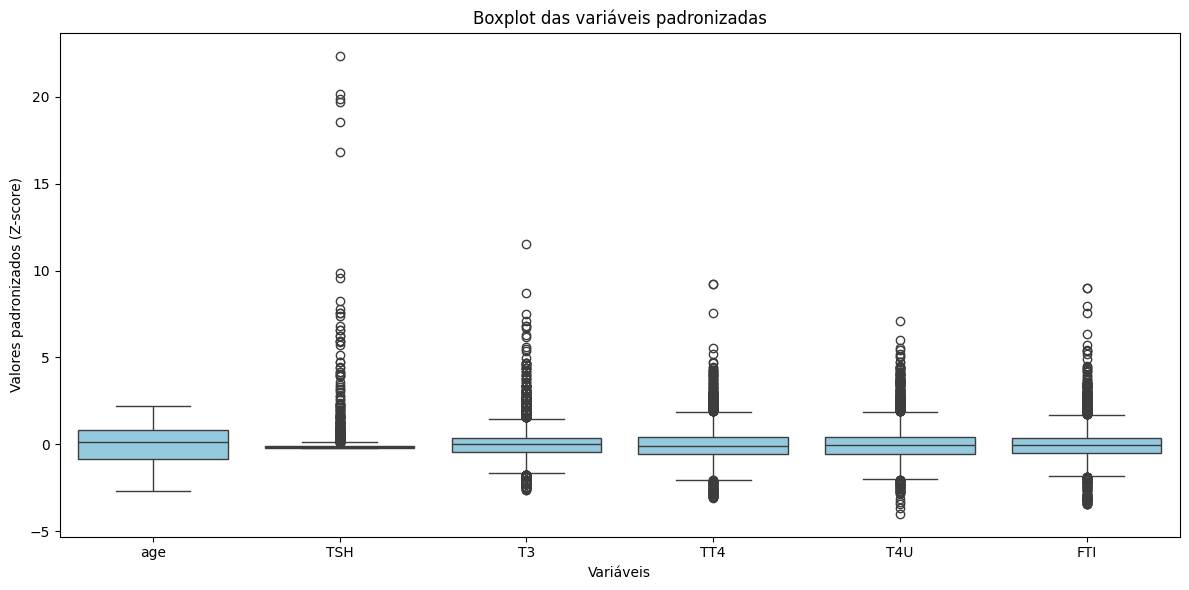

In [106]:
variaveis = ['age', 'TSH', 'T3', 'TT4', 'T4U', 'FTI']

# Cria um novo DataFrame padronizado só com essas variáveis para não atrapalhar a escala e posterior análise.
df_padronizado = pd.DataFrame(
    StandardScaler().fit_transform(df[variaveis]),
    columns=variaveis
)

# Boxplot para analisar distribuiçãp e outliers
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_padronizado, color='skyblue')

plt.title('Boxplot das variáveis padronizadas')
plt.xlabel('Variáveis')
plt.ylabel('Valores padronizados (Z-score)')

plt.tight_layout()
plt.show()

Como esperado os graficos apresentam grande assimetria no caso do tsh a forte assimetria a direita. Já para as demais excetuando idade apresentam assimetria a direita e a esquerda, com dados dispersos com valores de maximo e minimo bem distantes.

As variáveis estão relacionadas a avaliação da função tireoidiana de diferentes formas:
Variáveis e sua relação com hipertireoidismo
TSH	Geralmente baixo/suprimido no hipertireoidismo primário, devido ao feedback negativo dos hormônios tireoidianos.
T3	Geralmente elevado, podendo ocorrer a chamada T3-toxicosis, em que o T3 está alto mesmo quando o T4 ainda está normal.
TT4	Pode estar elevado, refletindo aumento dos hormônios tireoidianos circulantes.
T4U	É uma medida indireta relacionada à capacidade de ligação das proteínas transportadoras de hormônios tireoidianos. Pode ajudar na interpretação do TT4, mas não diagnostica hipertireoidismo isoladamente.
FTI	Índice calculado relacionado à quantidade de T4 disponível, ajustado pela capacidade de ligação. Pode estar elevado no hipertireoidismo.
Age	Não é um marcador bioquímico de hipertireoidismo. É uma variável demográfica que pode estar associada à distribuição da doença e ajudar na caracterização dos pacientes.

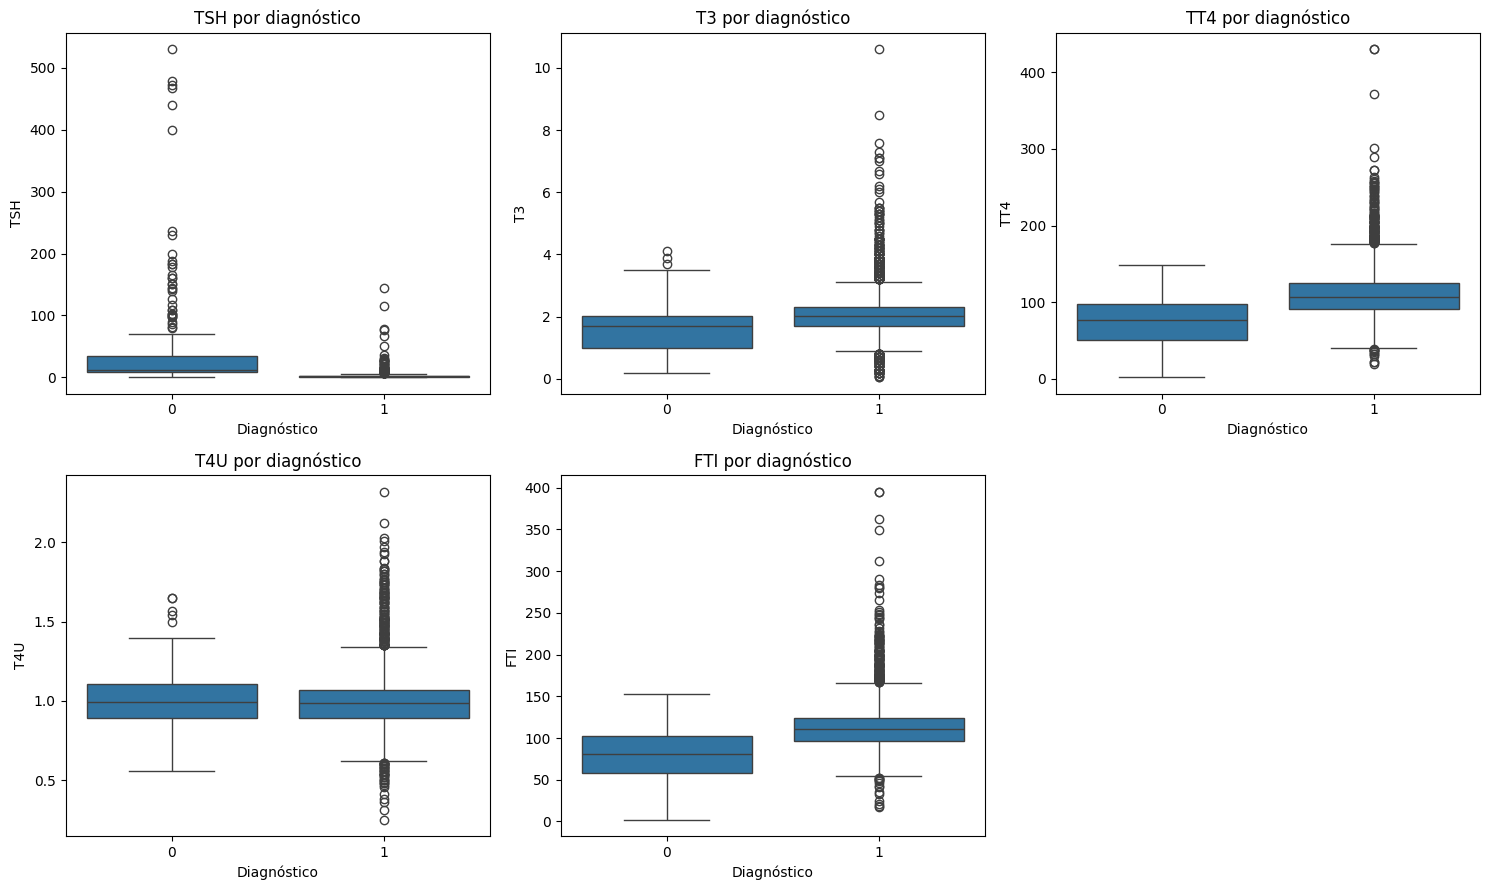

In [107]:
#comparando os marcadores com a presença de hipertireoidismo ou ausência:
variaveis10 = ['TSH', 'T3', 'TT4', 'T4U', 'FTI']

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for i, var in enumerate(variaveis10):
    sns.boxplot(
        data=df,
        x='binaryClass',
        y=var,
        ax=axes[i]
    )
    axes[i].set_title(f'{var} por diagnóstico')
    axes[i].set_xlabel('Diagnóstico')
    axes[i].set_ylabel(var)

# Remove o sexto gráfico vazio
fig.delaxes(axes[5])

plt.tight_layout()
plt.show()

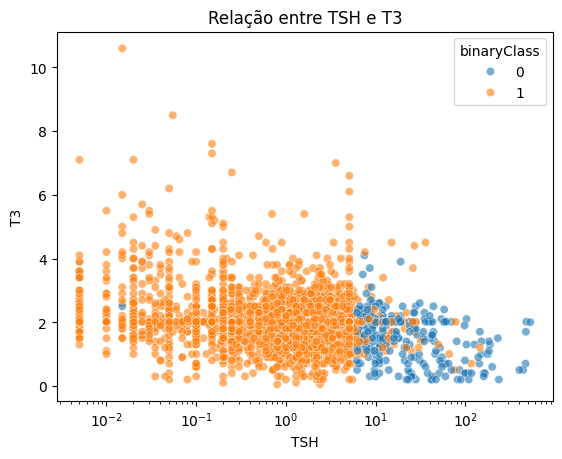

In [110]:
sns.scatterplot(
    data=df,
    x='TSH',
    y='T3',
    hue='binaryClass',
    alpha=0.6
)

plt.title('Relação entre TSH e T3')
plt.xlabel('TSH')
plt.ylabel('T3')
plt.xscale('log')
plt.show()

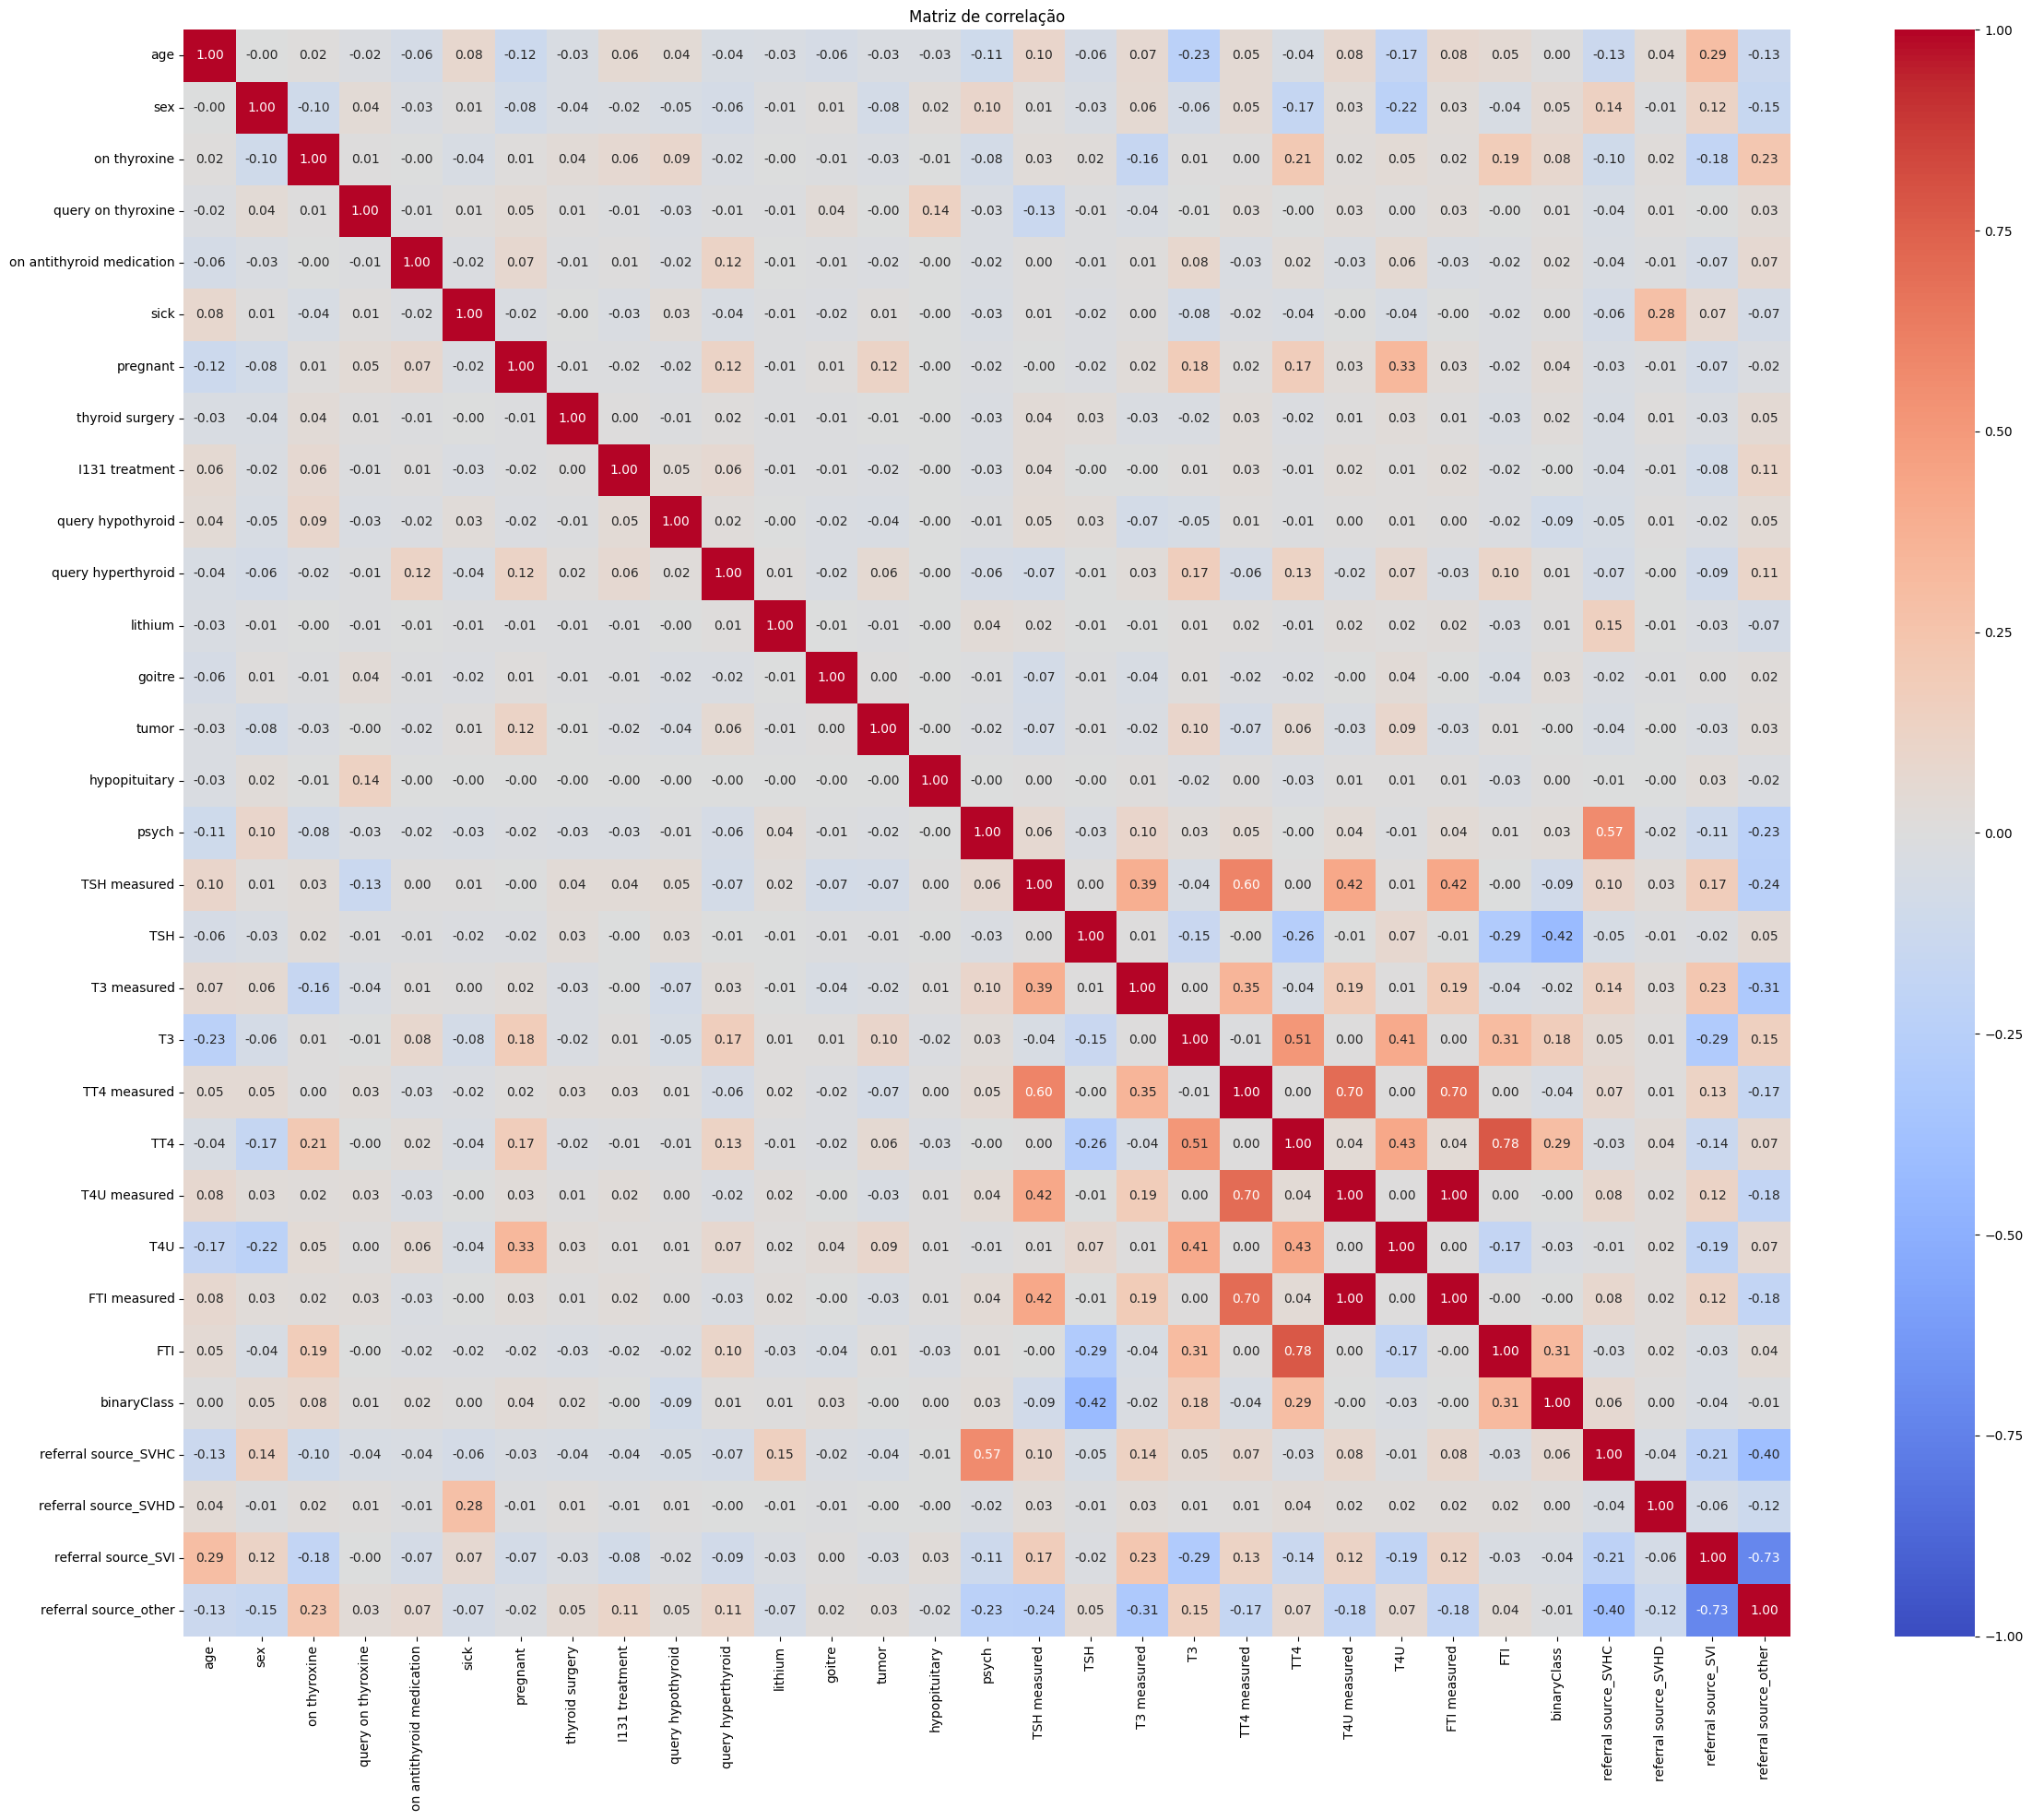

In [116]:
# Pega todas as variáveis numéricas para poder ver a relação entre elas e a variável target para entender quais apresentam correlação mais relevante.
df_numerico = df.select_dtypes(include='number')

# Calcula a correlação
correlacao = df_numerico.corr()

# Ajusta o tamanho de acordo com a quantidade de variáveis
n = len(correlacao.columns)
tamanho = max(10, n * 0.8)

plt.figure(figsize=(tamanho, tamanho * 0.8))

sns.heatmap(
    correlacao,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    vmin=-1,
    vmax=1,
    square=True
)

plt.title('Matriz de correlação')
plt.tight_layout()
plt.show()

Separação treino/teste feita antes das transformações sensíveis, sem vazamento de dados Modelo de classificação binária treinado e avaliado com métricas apropriadas, com interpretação do resultado.

Avalie o modelo com as métricas corretas para o problema e interprete o resultado.